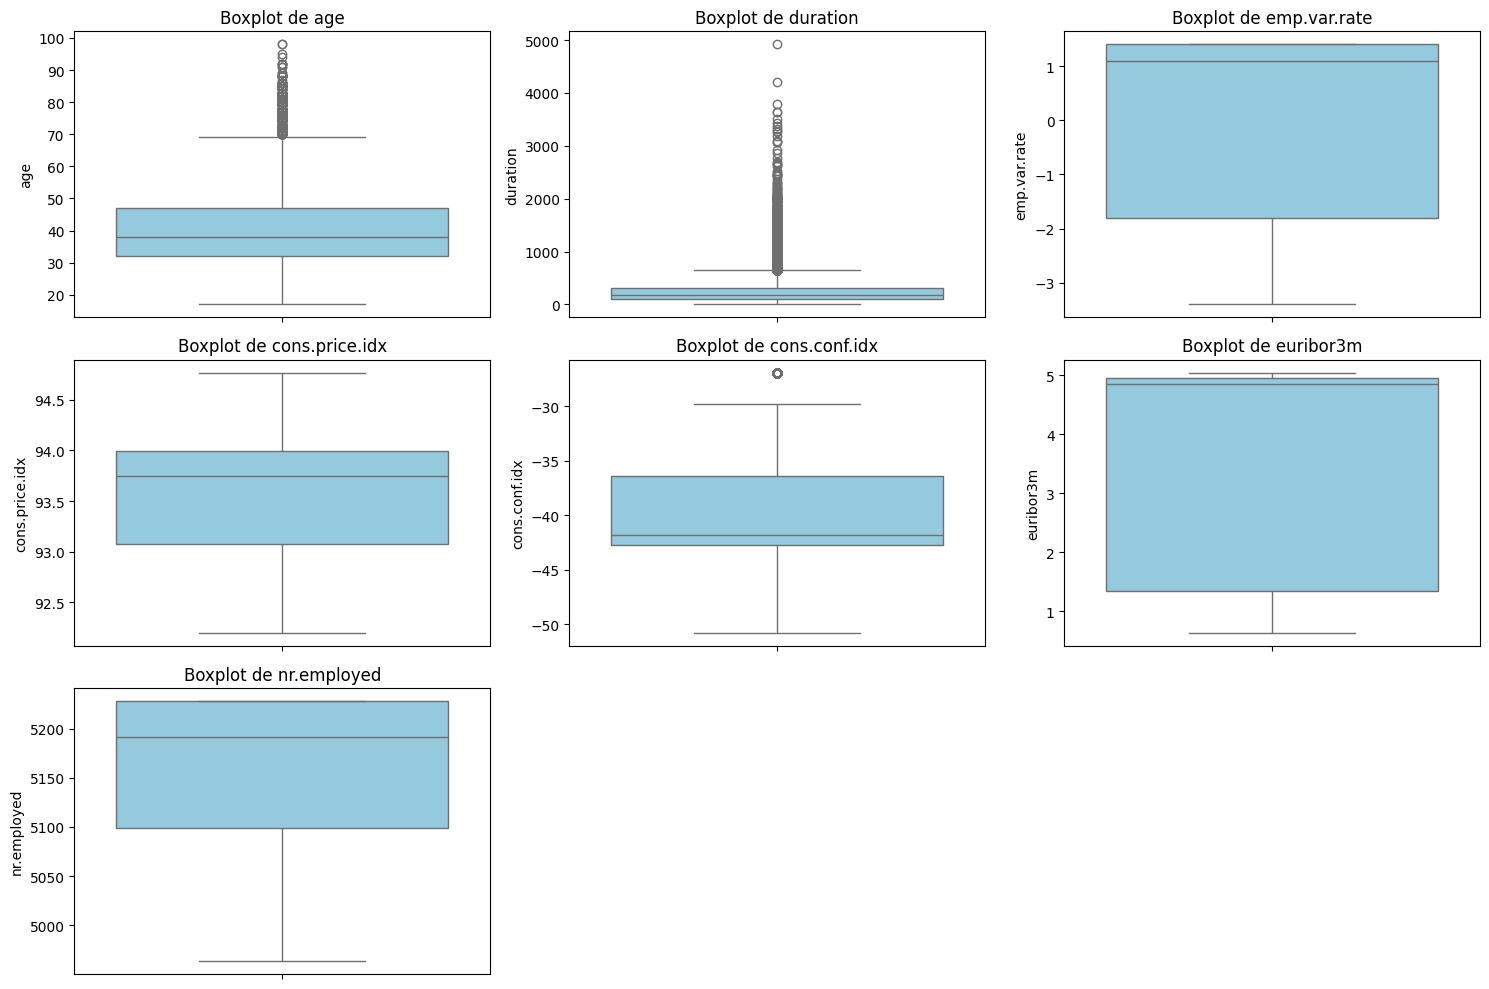

¡Outliers tratados exitosamente mediante Capping!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset (asumiendo que tus compañeros ya lo tienen listo, pero por si acaso)
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Variables estrictamente continuas recomendadas para buscar outliers
num_cols = ['age', 'duration', 'emp.var.rate', 'cons.price.idx', 
            'cons.conf.idx', 'euribor3m', 'nr.employed']

# 2. Visualización ANTES de limpiar (Crucial para el informe y el video)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# 3. Función para tratar outliers usando IQR (Técnica de Capping/Limitación)
# Nota: Es mejor limitar (capping) que eliminar filas para no perder datos valiosos de otras columnas.
def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Aplicar los límites
    df_capped = dataframe.copy()
    df_capped[column] = np.where(df_capped[column] > upper_bound, upper_bound,
                        np.where(df_capped[column] < lower_bound, lower_bound, df_capped[column]))
    return df_capped

# 4. Aplicar la función a las variables seleccionadas
df_clean = df.copy()
for col in num_cols:
    df_clean = cap_outliers_iqr(df_clean, col)

print("¡Outliers tratados exitosamente mediante Capping!")